In [ ]:
# Librerias
import os
import shutil
import matplotlib.pyplot as plt
from PIL import Image

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [1]:
train_path = '../data/raw/archive/train'
test_path = '../data/raw/archive/test'
processed_path = '../data/processed/full_data'

In [2]:
# Crear carpetas destino
os.makedirs(os.path.join(processed_path, 'cats'), exist_ok=True)
os.makedirs(os.path.join(processed_path, 'dogs'), exist_ok=True)

# Función para copiar las imágenes de un path a otro
def copiar_imagenes(origen):
    for file in os.listdir(origen):
        src = os.path.join(origen, file)
        if os.path.isfile(src) and file.lower().endswith('.jpg'):
            if file.startswith('cat'):
                shutil.copy(src, os.path.join(processed_path, 'cats', file))
            elif file.startswith('dog'):
                shutil.copy(src, os.path.join(processed_path, 'dogs', file))

# Copiar de train y luego de test
copiar_imagenes(train_path)
copiar_imagenes(test_path)

NameError: name 'os' is not defined

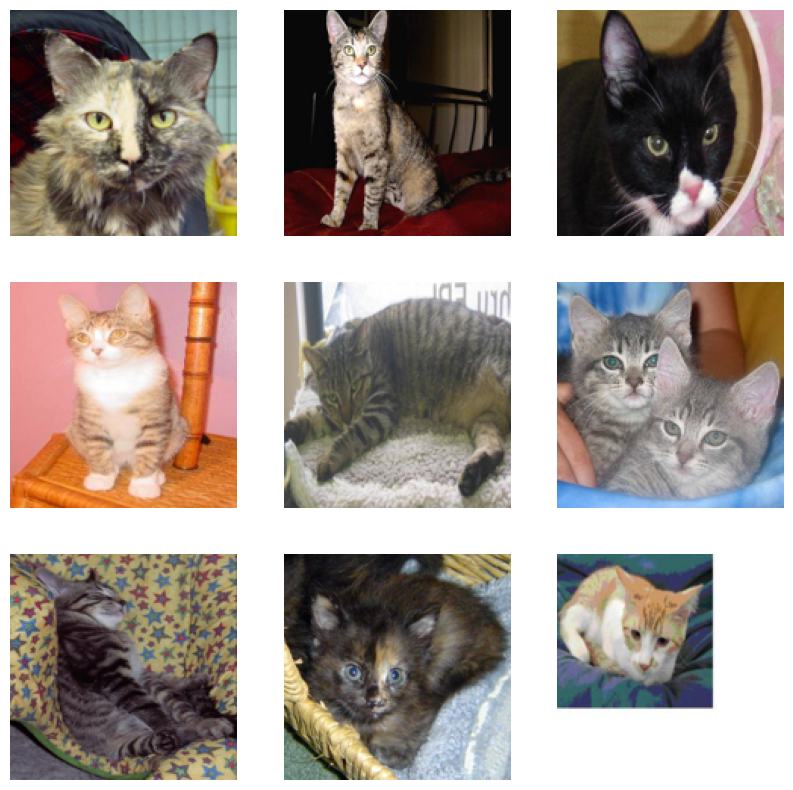

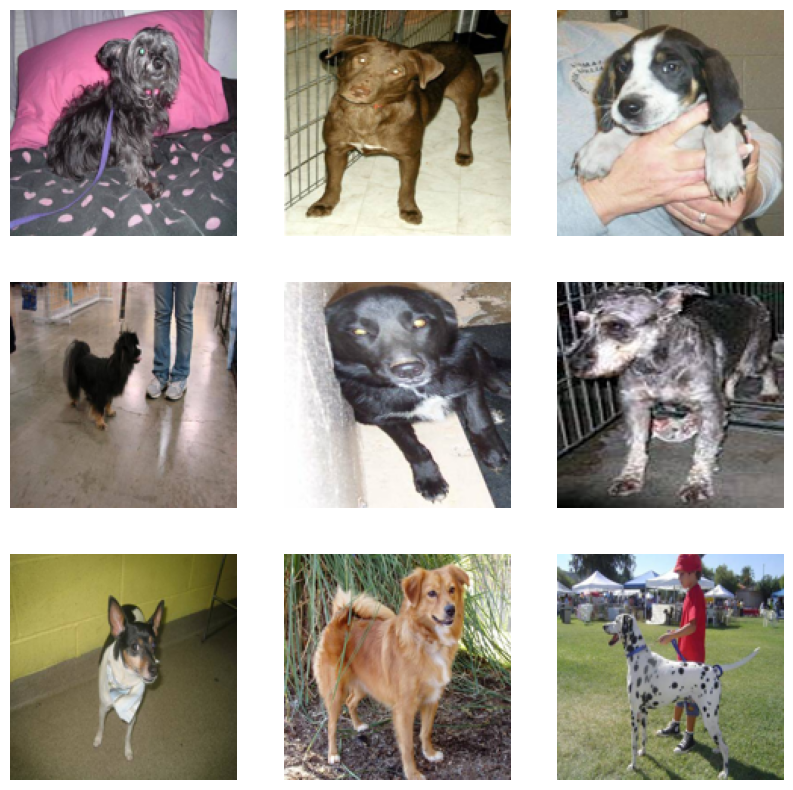

In [4]:
# =============================
# 👁️ Paso 3: Visualización de imágenes
# =============================
def mostrar_imagenes(ruta, clase):
    ruta_clase = os.path.join(ruta, clase)
    imagenes = os.listdir(ruta_clase)[:9]

    plt.figure(figsize=(10, 10))
    for i, img_name in enumerate(imagenes):
        img = Image.open(os.path.join(ruta_clase, img_name)).resize((150, 150))
        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.axis('off')
    plt.show()

mostrar_imagenes(test_path, 'cats')
mostrar_imagenes(train_path, 'dogs')


In [5]:
# 4. Creacion de generadores de datos 

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
train_gen = datagen.flow_from_directory(
    train_path,                # Carpeta raíz con subcarpetas por clase
    target_size=(150, 150),    # Tamaño de las imágenes
    batch_size=32,             # Tamaño del lote
    class_mode='binary',       # Tipo de etiqueta (binaria: 0 o 1)
    subset='training'          # Subconjunto de entrenamiento
)
val_gen = datagen.flow_from_directory(
    train_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='validation'        # Subconjunto de validación
)


Found 16000 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.


In [ ]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_gen = datagen.flow_from_directory(
test_path,                # Carpeta raíz con subcarpetas por clase
    target_size=(150, 150),    # Tamaño de las imágenes
    batch_size=32,             # Tamaño del lote
    class_mode='binary',       # Tipo de etiqueta (binaria: 0 o 1)
    subset='training'          # Subconjunto de entrenamiento
)
val_gen = datagen.flow_from_directory(
    test_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='validation'        # Subconjunto de validación
)


Found 4000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


: 

Gereracion y ajuste del Modelo 

In [ ]:
# =============================
#  Paso 5: Arquitectura del modelo CNN estilo VGG16
# =============================

model = Sequential()
model.add(Conv2D(64, (3,3), padding="same", activation="relu", input_shape=(224,224,3)))
model.add(Conv2D(64, (3,3), padding="same", activation="relu"))
model.add(MaxPool2D((2,2), strides=(2,2)))

model.add(Conv2D(128, (3,3), padding="same", activation="relu"))
model.add(Conv2D(128, (3,3), padding="same", activation="relu"))
model.add(MaxPool2D((2,2), strides=(2,2)))

model.add(Conv2D(256, (3,3), padding="same", activation="relu"))
model.add(Conv2D(256, (3,3), padding="same", activation="relu"))
model.add(Conv2D(256, (3,3), padding="same", activation="relu"))
model.add(MaxPool2D((2,2), strides=(2,2)))

model.add(Conv2D(512, (3,3), padding="same", activation="relu"))
model.add(Conv2D(512, (3,3), padding="same", activation="relu"))
model.add(Conv2D(512, (3,3), padding="same", activation="relu"))
model.add(MaxPool2D((2,2), strides=(2,2)))

model.add(Conv2D(512, (3,3), padding="same", activation="relu"))
model.add(Conv2D(512, (3,3), padding="same", activation="relu"))
model.add(Conv2D(512, (3,3), padding="same", activation="relu"))
model.add(MaxPool2D((2,2), strides=(2,2)))

model.add(Flatten())
model.add(Dense(4096, activation="relu"))
model.add(Dense(4096, activation="relu"))
model.add(Dense(2, activation="softmax"))  # 2 clases

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


c:\Users\7sean\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
